# 06 - Machine Learning Temperature Forecasting

## Objective

This notebook explores machine learning approaches for short-term indoor temperature forecasting.

The goal is to predict indoor temperature evolution over a 12-hour horizon, with future use in simulation and control-oriented applications such as MPC.

We compare:

- Persistence baseline
- Random Forest
- LSTM
- Physics-inspired LSTM using temperature change (ΔT)

In [75]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


## 1. Load and Clean Data

In [2]:
DATA_PATH = Path("../data/processed/TempHumData_27_4_26.csv")

# If running this notebook from a different location, update DATA_PATH accordingly.
df = pd.read_csv(DATA_PATH)

df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time").sort_index()

cutoff = "2026-02-22 17:00:00"
df = df[df.index >= cutoff]

#### Quick data quality check

In [3]:
print("Date range:", df.index.min(), "→", df.index.max())
print("\nMissing values:")
display(df.isna().sum())

# Verify hourly spacing
time_diffs = df.index.to_series().diff().dropna()
display(time_diffs.value_counts().head())


Date range: 2026-02-22 17:00:00 → 2026-04-27 05:00:00

Missing values:


temp_salon_c      0
temp_kids_c       4
hum_salon         0
hum_kids          4
temp_out_1_b_c    0
hum_out_1_b       0
temp_out_2_n_c    0
hum_out_2_n       0
dtype: int64

time
0 days 01:00:00    1522
0 days 02:00:00       1
Name: count, dtype: int64

#### Clean and interpolate small gaps

In [4]:
# Hourly grid, in case any timestamps are missing
df = df.resample("1h").mean()

# Interpolate short gaps only. Long initial gaps in outdoor sensors remain NaN and will be dropped later.
df = df.interpolate(method="time", limit=4)

# Optional: add mean outdoor conditions if both sides exist
df["temp_out_mean_c"] = df[["temp_out_1_b_c", "temp_out_2_n_c"]].mean(axis=1)
df["hum_out_mean"] = df[["hum_out_1_b", "hum_out_2_n"]].mean(axis=1)

# Solar / orientation proxy: south-facing outdoor sensor minus north-facing outdoor sensor.
# Confirm which outdoor sensor is north/south in your setup before interpreting physically.
df["solar_proxy_temp_delta"] = df["temp_out_2_n_c"] - df["temp_out_1_b_c"]

# display(df.tail())

## 2. Forecasting Target

Rather than only predicting absolute temperature directly, we also explore predicting the temperature change over the forecasting horizon:

ΔT = T(t + 12h) - T(t)

This formulation is more aligned with the physical nature of the problem, since thermal dynamics are driven by temperature differences and accumulated forcing over time.

In [5]:
forecast_horizon = 12

df["target_T_12h"] = df["temp_salon_c"].shift(-forecast_horizon)
df["target_deltaT_12h"] = df["target_T_12h"] - df["temp_salon_c"]

## 3. Feature Engineering

In [6]:
def add_time_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    hour = out.index.hour
    dayofyear = out.index.dayofyear

    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    out["doy_sin"] = np.sin(2 * np.pi * dayofyear / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * dayofyear / 365.25)

    out["is_weekend"] = (out.index.dayofweek >= 5).astype(int)
    return out


def add_lag_features(data, columns, lags):
    out = data.copy()
    for col in columns:
        for lag in lags:
            out[f"{col}_lag_{lag}h"] = out[col].shift(lag)
    return out


def add_rolling_features(data: pd.DataFrame, columns, windows) -> pd.DataFrame:
    out = data.copy()
    for col in columns:
        for window in windows:
            out[f"{col}_roll_mean_{window}h"] = out[col].rolling(window).mean()
            out[f"{col}_roll_std_{window}h"] = out[col].rolling(window).std()
    return out

In [7]:
feat = df.copy()
horizon = 12

feat["temp_diff_south"] = feat["temp_out_2_n_c"] - feat["temp_salon_c"]
feat["temp_diff_north"] = feat["temp_out_1_b_c"] - feat["temp_salon_c"]

feat["temp_salon_c_target_plus_1h"] = feat["temp_salon_c"].shift(-horizon)
feat["temp_kids_c_target_plus_1h"] = feat["temp_kids_c"].shift(-horizon)

# 3. Define target_cols AFTER have been created
target_cols = [
    "temp_salon_c_target_plus_1h",
    "temp_kids_c_target_plus_1h",
]

# 4. Sanity check: should return True
print("Targets exist in df_feat:")
for col in target_cols:
    print(col, col in feat.columns)

Targets exist in df_feat:
temp_salon_c_target_plus_1h True
temp_kids_c_target_plus_1h True


In [8]:
targets = ["temp_salon_c", "temp_kids_c"]

feat = add_time_features(feat)
lag_cols = [
    "temp_salon_c",
    "temp_kids_c",
    "temp_out_1_b_c",
    "temp_out_2_n_c",
    "temp_out_mean_c",
    "solar_proxy_temp_delta",
]

feat = add_lag_features(feat, columns=lag_cols, lags=[1, 2, 3, 6, 12, 24, 48])

feat = add_rolling_features(
    feat,
    columns=["temp_salon_c", "temp_kids_c"],
    windows=[2, 3, 6, 12, 24, 48]
)

feat = feat.dropna()

print(feat.shape)
display(feat.head())

# 7. Sanity check again
print("Columns with target:")
print([c for c in feat.columns if "target" in c])


(1465, 88)


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n,temp_out_mean_c,hum_out_mean,...,temp_kids_c_roll_mean_3h,temp_kids_c_roll_std_3h,temp_kids_c_roll_mean_6h,temp_kids_c_roll_std_6h,temp_kids_c_roll_mean_12h,temp_kids_c_roll_std_12h,temp_kids_c_roll_mean_24h,temp_kids_c_roll_std_24h,temp_kids_c_roll_mean_48h,temp_kids_c_roll_std_48h
time,,,,,,,,,,,,,,,,,,,,,
2026-02-24 17:00:00,17.30,19.10,64.40,56.07,15.75,53.24,19.64,41.33,17.695,47.285,...,19.110000,0.305123,18.803333,0.580781,18.245833,0.731840,18.560833,0.712887,18.691250,0.749030
2026-02-24 18:00:00,17.31,18.55,64.92,57.61,14.83,55.83,16.20,49.31,15.515,52.570,...,19.023333,0.440038,18.918333,0.395344,18.283333,0.735210,18.492917,0.624030,18.660208,0.722344
2026-02-24 19:00:00,18.29,19.28,68.54,58.50,14.24,59.77,15.01,55.48,14.625,57.625,...,18.976667,0.380307,19.063333,0.324879,18.386667,0.783458,18.485417,0.612883,18.652500,0.713477
2026-02-24 20:00:00,18.83,19.78,68.50,58.88,13.76,62.90,14.31,59.72,14.035,61.310,...,19.203333,0.618574,19.156667,0.439211,18.588333,0.806292,18.508333,0.651030,18.651250,0.711401
2026-02-24 21:00:00,18.56,19.64,69.60,61.37,13.36,63.33,13.74,60.62,13.550,61.975,...,19.566667,0.257941,19.295000,0.438896,18.766667,0.779922,18.530833,0.681009,18.653333,0.714200


Columns with target:
['target_T_12h', 'target_deltaT_12h', 'temp_salon_c_target_plus_1h', 'temp_kids_c_target_plus_1h']


## 4. Train/test split — chronological, not random

Since this is a time-series forecasting problem, the train/test split is performed chronologically.

This avoids leakage from future observations into the training set.

In [9]:
# 8. X = all except targets
X = feat.drop(columns=target_cols)

# 9. y = Only targets
y = feat[target_cols]

print("X columns sample:")
print(X.columns[:10].tolist())

print("y columns:")
print(y.columns.tolist())

split_idx = int(len(feat) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.index.min(), "→", X_train.index.max(), X_train.shape)
print("Test:", X_test.index.min(), "→", X_test.index.max(), X_test.shape)


X columns sample:
['temp_salon_c', 'temp_kids_c', 'hum_salon', 'hum_kids', 'temp_out_1_b_c', 'hum_out_1_b', 'temp_out_2_n_c', 'hum_out_2_n', 'temp_out_mean_c', 'hum_out_mean']
y columns:
['temp_salon_c_target_plus_1h', 'temp_kids_c_target_plus_1h']
Train: 2026-02-24 17:00:00 → 2026-04-14 12:00:00 (1172, 86)
Test: 2026-04-14 13:00:00 → 2026-04-26 17:00:00 (293, 86)


## 5. Baseline: Persistence Model

As a reference, we use a persistence model:

T(t + 12h) ≈ T(t)

This is a simple but important benchmark. Any machine learning model should outperform this baseline to be useful.

In [53]:
baseline_map = {
    "temp_salon_c_target_plus_1h": "temp_salon_c",
    "temp_kids_c_target_plus_1h": "temp_kids_c",
}

for target_col, current_col in baseline_map.items():
    y_true = y_test[target_col]
    y_pred = X_test[current_col]

    mae_persistence = mean_absolute_error(y_true, y_pred)
    rmse_persistence = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"Persistence {target_col}: MAE={mae_persistence:.3f} °C | RMSE={rmse_persistence:.3f} °C")

Persistence temp_salon_c_target_plus_1h: MAE=0.244 °C | RMSE=0.330 °C
Persistence temp_kids_c_target_plus_1h: MAE=0.264 °C | RMSE=0.368 °C


## 6. Random Forest Benchmark

A Random Forest model is used as a classical machine learning benchmark.

Although it can learn nonlinear relationships between features and target temperature, it does not explicitly model temporal dynamics unless they are encoded through lagged or rolling features.

In [54]:
rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
rf_pred = pd.DataFrame(rf.predict(X_test), index=X_test.index, columns=target_cols)

for col in target_cols:
    mae_rf = mean_absolute_error(y_test[col], rf_pred[col])
    rmse_rf = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"Random Forest {col}: MAE={mae_rf:.3f} °C | RMSE={rmse_rf:.3f} °C")


Random Forest temp_salon_c_target_plus_1h: MAE=0.246 °C | RMSE=0.368 °C
Random Forest temp_kids_c_target_plus_1h: MAE=0.276 °C | RMSE=0.368 °C


### Plot predictions

Salon


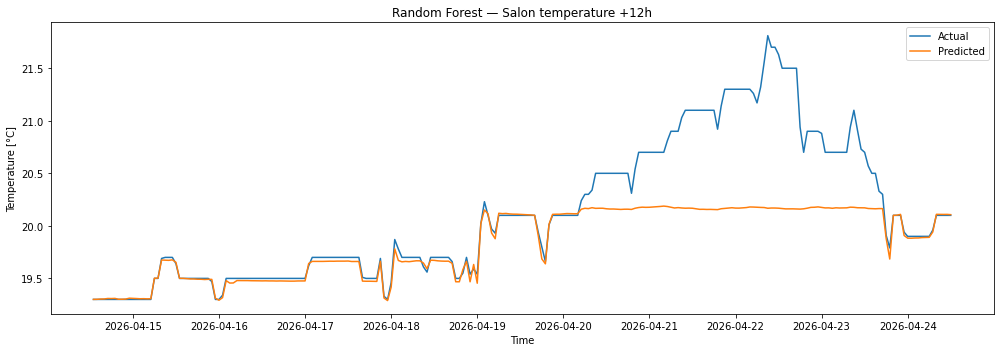

Kids


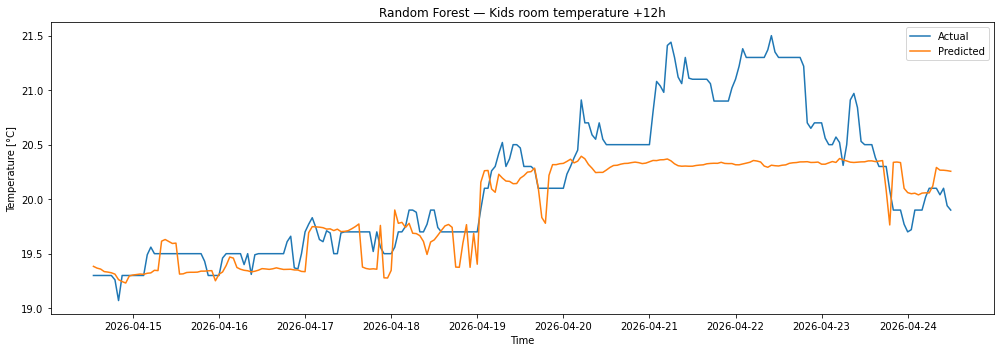

In [67]:
def plot_prediction(y_true, y_pred, target_col, title, n=240):
    plt.figure(figsize=(14, 5))
    plt.plot(y_true[target_col].iloc[:n].index, y_true[target_col].iloc[:n], label="Actual")
    plt.plot(y_pred[target_col].iloc[:n].index, y_pred[target_col].iloc[:n], label="Predicted")
    plt.title(title)
    plt.ylabel("Temperature [°C]")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    room = title.split(" ")[3]
    full_path = f"../reports/figures/06_ml_temperature_prediction/RandomForest_{room}.png"
    plt.savefig(full_path, dpi=300, facecolor='white')
    
    plt.show()


plot_prediction(y_test, rf_pred, target_cols[0], "Random Forest — Salon temperature +12h")
plot_prediction(y_test, rf_pred, target_cols[1], "Random Forest — Kids room temperature +12h")


## 7. LSTM: Direct Temperature Forecast

The LSTM model is introduced to better capture temporal dependencies in the data.

Unlike Random Forest, it processes sequences of past observations and can learn time-dependent patterns relevant to indoor temperature evolution.

### Data preparation for sequence modeling

In [16]:
# Use initial hourly df, not the one for RF
lstm_df = df.copy()

# Time features
lstm_df = add_time_features(lstm_df)

# Physics-inspired features
lstm_df["solar_proxy_temp_delta"] = (
    lstm_df["temp_out_2_n_c"] - lstm_df["temp_out_1_b_c"]
)

lstm_df["temp_out_mean_c"] = (
    lstm_df["temp_out_2_n_c"] + lstm_df["temp_out_1_b_c"]
) / 2

lstm_df["salon_outdoor_delta"] = (
    lstm_df["temp_out_mean_c"] - lstm_df["temp_salon_c"]
)

lstm_df["kids_outdoor_delta"] = (
    lstm_df["temp_out_mean_c"] - lstm_df["temp_kids_c"]
)

lstm_df = lstm_df.dropna()

### Define features/targets

In [17]:
lstm_features = [
    "temp_salon_c",
    "temp_kids_c",
    "temp_out_1_b_c",
    "temp_out_2_n_c",
    "hum_salon",
    "hum_kids",
    "hum_out_1_b",
    "hum_out_2_n",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "solar_proxy_temp_delta",
    "temp_out_mean_c",
    "salon_outdoor_delta",
    "kids_outdoor_delta",
]

lstm_targets = [
    "temp_salon_c",
    "temp_kids_c",
]

### Sequence creator

In [18]:
def create_lstm_sequences(df, feature_cols, target_cols, seq_len=24, horizon=12):
    X, y, target_times = [], [], []
    
    feature_values = df[feature_cols].values
    target_values = df[target_cols].values
    index_values = df.index

    for i in range(len(df) - seq_len - horizon + 1):
        X.append(feature_values[i:i + seq_len])
        y.append(target_values[i + seq_len + horizon - 1])
        target_times.append(index_values[i + seq_len + horizon - 1])
        
    return np.array(X), np.array(y), pd.DatetimeIndex(target_times)


### Scaling

In [19]:
seq_len = 24
horizon = 12

split_idx_raw = int(len(lstm_df) * 0.8)

train_df = lstm_df.iloc[:split_idx_raw].copy()
test_df = lstm_df.iloc[split_idx_raw - seq_len - horizon + 1:].copy()

In [20]:
# Fit only on train dataset
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_df[lstm_features])
target_scaler.fit(train_df[lstm_targets])

train_scaled = train_df.copy()
test_scaled = test_df.copy()

train_scaled[lstm_features] = feature_scaler.transform(train_df[lstm_features])
test_scaled[lstm_features] = feature_scaler.transform(test_df[lstm_features])

train_scaled[lstm_targets] = target_scaler.transform(train_df[lstm_targets])
test_scaled[lstm_targets] = target_scaler.transform(test_df[lstm_targets])


### Create sequences

In [21]:
X_train_lstm, y_train_lstm, train_times = create_lstm_sequences(
    train_scaled,
    lstm_features,
    lstm_targets,
    seq_len=seq_len,
    horizon=horizon
)

X_test_lstm, y_test_lstm, test_times = create_lstm_sequences(
    test_scaled,
    lstm_features,
    lstm_targets,
    seq_len=seq_len,
    horizon=horizon
)

print("X_train:", X_train_lstm.shape)
print("y_train:", y_train_lstm.shape)
print("X_test:", X_test_lstm.shape)
print("y_test:", y_test_lstm.shape)

X_train: (1175, 24, 16)
y_train: (1175, 2)
X_test: (303, 24, 16)
y_test: (303, 2)


In [22]:
model_lstm = Sequential([
    LSTM(32, input_shape=(seq_len, len(lstm_features))),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(len(lstm_targets))
])

model_lstm.compile(
    optimizer="adam",
    loss="mae"
)

model_lstm.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           6,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,834 (26.70 KB)

 Trainable params: 6,834 (26.70 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.6582 - val_loss: 0.6089
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4599 - val_loss: 0.6049
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4343 - val_loss: 0.5272
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3859 - val_loss: 0.5764
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3962 - val_loss: 0.5764
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3922 - val_loss: 0.5540
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3740 - val_loss: 0.5585
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3733 - val_loss: 0.5682
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3505 - val_loss: 0.5713
Epoch 10/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3619 - val_loss: 0.6049
Epoch 11/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3557 - val_loss: 0.6061
Epoch 12/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

### Predictions and Inverse scaling

In [24]:
pred_scaled = model_lstm. predict(X_test_lstm)

pred_lstm = target_scaler.inverse_transform(pred_scaled)
actual_lstm = target_scaler.inverse_transform(y_test_lstm)

pred_lstm_df = pd.DataFrame(
    pred_lstm,
    index=test_times,
    columns=[f"pred_{c}_plus_{horizon}h" for c in lstm_targets]
)

actual_lstm_df = pd.DataFrame(
    actual_lstm,
    index=test_times,
    columns=[f"actual_{c}_plus_{horizon}h" for c in lstm_targets]
)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [55]:
for i, target in enumerate(lstm_targets):
    y_true = actual_lstm[:, i]
    y_pred = pred_lstm[:, i]
    
    mae_lstm = mean_absolute_error(y_true, y_pred)
    rmse_lstm = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"LSTM {target} + {horizon}h: MAE={mae_lstm:.3f} °C | RMSE={rmse_lstm:.3f} °C")


LSTM temp_salon_c + 12h: MAE=0.466 °C | RMSE=0.605 °C
LSTM temp_kids_c + 12h: MAE=0.396 °C | RMSE=0.508 °C


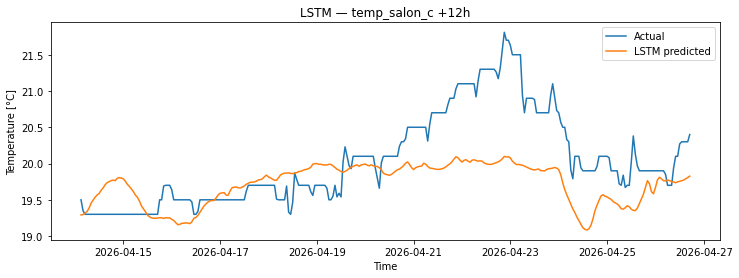

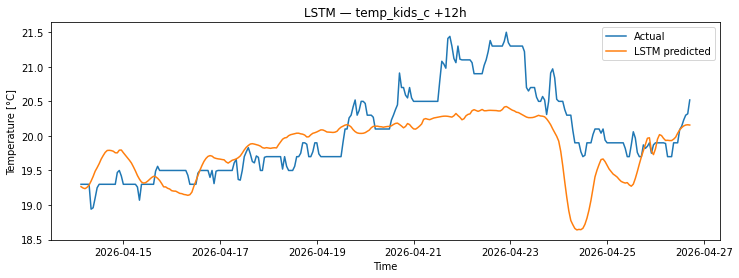

In [69]:
for i, target in enumerate(lstm_targets):
    plt.figure(figsize=(12, 4))
    plt.plot(test_times, actual_lstm[:, i], label="Actual")
    plt.plot(test_times, pred_lstm[:, i], label="LSTM predicted")
    plt.title(f"LSTM — {target} +{horizon}h")
    plt.xlabel("Time")
    plt.ylabel("Temperature [°C]")
    plt.legend()
    room = target.split("_")[1]
    full_path = f"../reports/figures/06_ml_temperature_prediction/LSTM_{room}.png"
    plt.savefig(full_path, dpi=300, facecolor='white')
    plt.show()

## 8. Physics-Inspired LSTM: Predicting Temperature Change

The previous models attempt to learn future temperature directly.

Here we introduce a more physically meaningful formulation.

Instead of predicting T(t+12h), the model predicts:

ΔT = T(t+12h) - T(t)

The final temperature is reconstructed afterwards.

This shifts the learning task from absolute state estimation to thermal evolution prediction.

In [27]:
# Physics-informed LSTM setup
# We start fresh from the clean hourly dataframe, not from RF features or previous LSTM tensors.

phys_df = df.copy()

# Add time features
phys_df = add_time_features(phys_df)
print(phys_df.columns)

# Physics-inspired explanatory variables
phys_df["outdoor_mean_c"] = (
    phys_df["temp_out_1_b_c"] + phys_df["temp_out_2_n_c"]
) / 2

phys_df["solar_proxy_temp_delta"] = (
    phys_df["temp_out_2_n_c"] - phys_df["temp_out_1_b_c"]
)

phys_df["salon_heat_loss_driver"] = (
    phys_df["outdoor_mean_c"] - phys_df["temp_salon_c"]
)

phys_df["kids_heat_loss_driver"] = (
    phys_df["outdoor_mean_c"] - phys_df["temp_kids_c"]
)

# Accumulated / smoothed external forcing
phys_df["solar_proxy_roll_6h"] = (
    phys_df["solar_proxy_temp_delta"].rolling(6).mean()
)

phys_df["solar_proxy_roll_12h"] = (
    phys_df["solar_proxy_temp_delta"].rolling(12).mean()
)

phys_df["outdoor_mean_roll_12h"] = (
    phys_df["outdoor_mean_c"].rolling(12).mean()
)

phys_df = phys_df.dropna()

print(phys_df.shape)
phys_df.head()


Index(['temp_salon_c', 'temp_kids_c', 'hum_salon', 'hum_kids',
       'temp_out_1_b_c', 'hum_out_1_b', 'temp_out_2_n_c', 'hum_out_2_n',
       'temp_out_mean_c', 'hum_out_mean', 'solar_proxy_temp_delta',
       'target_T_12h', 'target_deltaT_12h', 'hour_sin', 'hour_cos', 'doy_sin',
       'doy_cos', 'is_weekend'],
      dtype='object')
(1502, 24)


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n,temp_out_mean_c,hum_out_mean,...,hour_cos,doy_sin,doy_cos,is_weekend,outdoor_mean_c,salon_heat_loss_driver,kids_heat_loss_driver,solar_proxy_roll_6h,solar_proxy_roll_12h,outdoor_mean_roll_12h
time,,,,,,,,,,,,,,,,,,,,,
2026-02-23 04:00:00,17.90,18.50,67.10,63.40,7.91,72.41,8.50,70.17,8.205,71.290,...,5.000000e-01,0.80098,0.598691,0,8.205,-9.695,-10.295,0.738333,1.517500,9.042917
2026-02-23 05:00:00,17.84,18.42,67.10,64.35,8.16,72.16,8.64,70.04,8.400,71.100,...,2.588190e-01,0.80098,0.598691,0,8.400,-9.440,-10.020,0.701667,0.964167,8.622083
2026-02-23 06:00:00,17.70,18.30,67.10,64.40,8.28,70.39,8.74,68.27,8.510,69.330,...,6.123234e-17,0.80098,0.598691,0,8.510,-9.190,-9.790,0.635000,0.802500,8.462083
2026-02-23 07:00:00,17.70,18.13,67.10,61.72,8.24,69.99,8.64,68.44,8.440,69.215,...,-2.588190e-01,0.80098,0.598691,0,8.440,-9.260,-9.690,0.545000,0.715833,8.364583
2026-02-23 08:00:00,17.70,17.07,66.42,50.27,9.45,66.90,9.16,66.56,9.305,66.730,...,-5.000000e-01,0.80098,0.598691,0,9.305,-8.395,-7.765,0.380000,0.606667,8.377500


In [28]:
# Instead of predicting abso;ute future temperature,
# we predict temperature change over the forecast horizon.

phys_horizon = 12

phys_df["delta_temp_salon_c"] = (
    phys_df["temp_salon_c"].shift(-phys_horizon) - phys_df["temp_salon_c"]
)

phys_df["delta_temp_kids_c"] = (
    phys_df["temp_kids_c"].shift(-phys_horizon) - phys_df["temp_kids_c"]
)

phys_df = phys_df.dropna()

phys_features = [
    "temp_salon_c",
    "temp_kids_c",
    "temp_out_1_b_c",
    "temp_out_2_n_c",
    "hum_salon",
    "hum_kids",
    "hum_out_1_b",
    "hum_out_2_n",

    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",

    "outdoor_mean_c",
    "solar_proxy_temp_delta",
    "salon_heat_loss_driver",
    "kids_heat_loss_driver",
    "solar_proxy_roll_6h",
    "solar_proxy_roll_12h",
    "outdoor_mean_roll_12h",
]

phys_targets = [
    "delta_temp_salon_c",
    "delta_temp_kids_c",
]

print("Physics-informed features:", len(phys_features))
print("Physics-informed targets:", phys_targets)

Physics-informed features: 19
Physics-informed targets: ['delta_temp_salon_c', 'delta_temp_kids_c']


In [29]:
# Sequence creation for physics-informed LSTM

phys_seq_len = 24

X_phys, y_phys, phys_target_times = create_lstm_sequences(
    phys_df,
    feature_cols=phys_features,
    target_cols=phys_targets,
    seq_len=phys_seq_len,
    horizon=1
)

print("X_phys:", X_phys.shape)
print("y_phys:", y_phys.shape)
print("target times:", phys_target_times[0], "→", phys_target_times[-1])

X_phys: (1466, 24, 19)
y_phys: (1466, 2)
target times: 2026-02-24 04:00:00 → 2026-04-26 05:00:00


In [30]:
# Chronoligical split
phys_split = int(len(X_phys) * 0.8)

X_phys_train_raw = X_phys[:phys_split]
X_phys_test_raw = X_phys[phys_split:]

y_phys_train_raw = y_phys[:phys_split]
y_phys_test_raw = y_phys[phys_split:]

phys_test_times = phys_target_times[phys_split:]

print("Train:", X_phys_train_raw.shape, y_phys_train_raw.shape)
print("Test:", X_phys_test_raw.shape, y_phys_test_raw.shape)


Train: (1172, 24, 19) (1172, 2)
Test: (294, 24, 19) (294, 2)


In [31]:
# Scaling
# For 3D LSTM input, we reshape temporarily to 2D for scaler fitting.

from sklearn.preprocessing import StandardScaler

n_train, seq_len_train, n_features = X_phys_train_raw.shape
n_test = X_phys_test_raw.shape[0]

phys_feature_scaler = StandardScaler()
phys_target_scaler = StandardScaler()

X_train_2d = X_phys_train_raw.reshape(-1, n_features)
X_test_2d = X_phys_test_raw.reshape(-1, n_features)

X_phys_train_scaled = phys_feature_scaler.fit_transform(X_train_2d).reshape(
    n_train, seq_len_train, n_features
)

X_phys_test_scaled = phys_feature_scaler.transform(X_test_2d).reshape(
    n_test, seq_len_train, n_features
)

y_phys_train_scaled = phys_target_scaler.fit_transform(y_phys_train_raw)
y_phys_test_scaled = phys_target_scaler.transform(y_phys_test_raw)

print("Scaled X train:", X_phys_train_scaled.shape)
print("Scaled y train:", y_phys_train_scaled.shape)


Scaled X train: (1172, 24, 19)
Scaled y train: (1172, 2)


In [32]:
# Physics-informed LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

phys_lstm_model = Sequential([
    LSTM(32, input_shape=(phys_seq_len, len(phys_features))),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(len(phys_targets))
])

phys_lstm_model.compile(
    optimizer="adam",
    loss="mae"
)

phys_lstm_model.summary()

C:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 32)                  │           6,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,218 (28.20 KB)

 Trainable params: 7,218 (28.20 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
phys_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

phys_history = phys_lstm_model.fit(
    X_phys_train_scaled,
    y_phys_train_scaled,
    validation_data=(X_phys_test_scaled, y_phys_test_scaled),
    epochs=100,
    batch_size=16,
    callbacks=[phys_early_stop],
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.7650 - val_loss: 0.3140
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5853 - val_loss: 0.2361
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4852 - val_loss: 0.2220
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4498 - val_loss: 0.2380
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4387 - val_loss: 0.2386
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4127 - val_loss: 0.2350
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3984 - val_loss: 0.2254
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3921 - val_loss: 0.2317
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3952 - val_loss: 0.2287
Epoch 10/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3752 - val_loss: 0.2382
Epoch 11/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3708 - val_loss: 0.2243
Epoch 12/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

### Reconstructing ΔT predictions

In [34]:
# Predict scaled ΔT
phys_pred_delta_scaled = phys_lstm_model.predict(X_phys_test_scaled)

# Convert predicted and actual ΔΤ back to °C
phys_pred_delta = phys_target_scaler.inverse_transform(phys_pred_delta_scaled)
phys_actual_delta = phys_target_scaler.inverse_transform(y_phys_test_scaled)

print("Predicted ΔT shape:", phys_pred_delta.shape)
print("Actual ΔT shape:", phys_actual_delta.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Predicted ΔT shape: (294, 2)
Actual ΔT shape: (294, 2)


### Reconstruct predicted temperatures

In [35]:
# For each target time T(t + horizon), base time is T(t)
phys_base_times = phys_test_times - pd.Timedelta(hours=phys_horizon)

# Get base temperature from original physics dataframe
phys_base_temps = phys_df.loc[
    phys_base_times,
    ["temp_salon_c", "temp_kids_c"]
].values

# Reconstruct temperatures
phys_pred_temp = phys_base_temps + phys_pred_delta
phys_actual_temp = phys_base_temps + phys_actual_delta

print("Base temps shape:", phys_base_temps.shape)
print("Predicted temps shape:", phys_pred_temp.shape)
print("Actual temps shape:", phys_actual_temp.shape)


Base temps shape: (294, 2)
Predicted temps shape: (294, 2)
Actual temps shape: (294, 2)


In [56]:
phys_temp_targets = [
    "temp_salon_c",
    "temp_kids_c",
]

for i, target in enumerate(phys_temp_targets):
    mae_delta_lstm = mean_absolute_error(phys_actual_temp[:, i], phys_pred_temp[:, i])
    rmse_delta_lstm = np.sqrt(mean_squared_error(phys_actual_temp[:, i], phys_pred_temp[:, i]))
    # rmse = mean_squared_error(phys_actual_temp[:, i], phys_pred_temp[:, i])
    
    print(
        f"Phsyics-informed LSTM {target} +{phys_horizon}h: "
        f"MAE={mae_delta_lstm:.3f} °C | RMSE={rmse_delta_lstm:.3f} °C"
    )

Phsyics-informed LSTM temp_salon_c +12h: MAE=0.196 °C | RMSE=0.253 °C
Phsyics-informed LSTM temp_kids_c +12h: MAE=0.238 °C | RMSE=0.318 °C


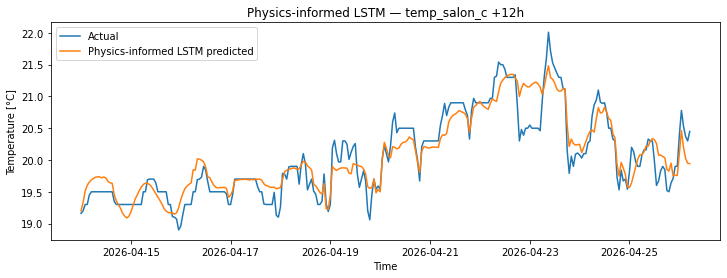

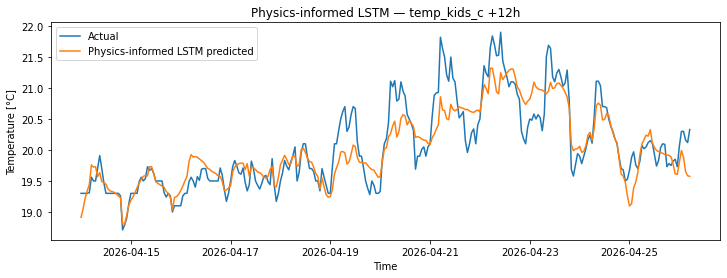

In [70]:
for i, target in enumerate(phys_temp_targets):
    plt.figure(figsize=(12, 4))
    plt.plot(phys_test_times, phys_actual_temp[:, i], label="Actual")
    plt.plot(phys_test_times, phys_pred_temp[:, i], label="Physics-informed LSTM predicted")
    plt.title(f"Physics-informed LSTM — {target} +{phys_horizon}h")
    plt.xlabel("Time")
    plt.ylabel("Temperature [°C]")
    plt.legend()
    room = target.split("_")[1]
    full_path = f"../reports/figures/06_ml_temperature_prediction/Physics_LSTM_{room}.png"
    plt.savefig(full_path, dpi=300, facecolor='white')
    plt.show()

### Plot predicted ΔT vs actual ΔT

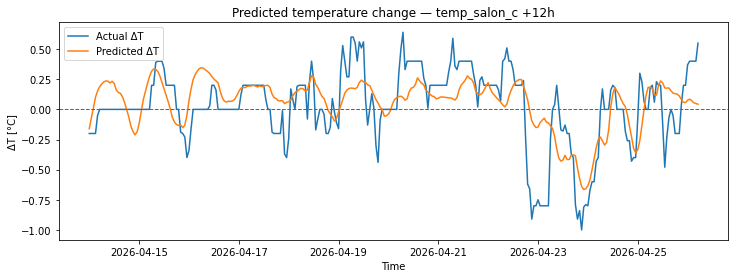

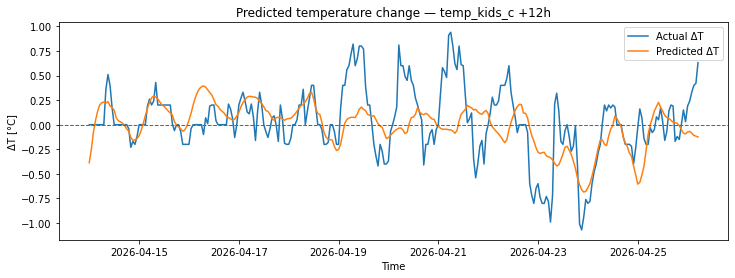

In [71]:
for i, target in enumerate(phys_temp_targets):
    plt.figure(figsize=(12, 4))
    plt.plot(phys_test_times, phys_actual_delta[:, i], label="Actual ΔT")
    plt.plot(phys_test_times, phys_pred_delta[:, i], label="Predicted ΔT")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Predicted temperature change — {target} +{phys_horizon}h")
    plt.xlabel("Time")
    plt.ylabel("ΔT [°C]")
    plt.legend()
    room = target.split("_")[1]
    full_path = f"../reports/figures/06_ml_temperature_prediction/Physics_ΔΤ_LSTM_{room}.png"
    plt.savefig(full_path, dpi=300, facecolor='white')
    plt.show()

## 9. Residual Feature Extension

Additional physics-inspired features are added to help the model capture thermal forcing, such as indoor-outdoor temperature difference and solar exposure proxy.

This section evaluates whether these engineered features improve forecasting performance.

In [39]:
# Estimate simple thermal coefficients k from training data
# dT/dt = k * (T_out - T_in)

res_df = df.copy()
res_df = add_time_features(res_df)
res_df["outdoor_mean_c"] = (
    res_df["temp_out_1_b_c"] + res_df["temp_out_2_n_c"]
) / 2

# Approximate hourly dT/dt
res_df["dTdt_salon"] = res_df["temp_salon_c"].diff()
res_df["dTdt_kids"] = res_df["temp_kids_c"].diff()

# Thermal drivers
res_df["driver_salon"] = res_df["outdoor_mean_c"] - res_df["temp_salon_c"]
res_df["driver_kids"] = res_df["outdoor_mean_c"] - res_df["temp_kids_c"]

res_df = res_df.dropna().copy()

# Use only training part to estimate k
res_split_raw = int(len(res_df) * 0.8)
res_train_df = res_df.iloc[:res_split_raw]

def estimate_k(driver, dTdt):
    numerator = np.sum(driver * dTdt)
    denominator = np.sum(driver ** 2)
    return numerator / denominator
    

k_salon = estimate_k(
    res_train_df["driver_salon"].values,
    res_train_df["dTdt_salon"].values,
)

k_kids = estimate_k(
    res_train_df["driver_kids"].values,
    res_train_df["dTdt_kids"].values,
)

print(f"k_salon = {k_salon:.5f} 1/h")
print(f"k_kids = {k_kids:.5f} 1/h")

k_salon = 0.00300 1/h
k_kids = 0.00421 1/h


In [40]:
# Thermal residual: what the simple heat-transfer model does NOT explain
res_df["thermal_residual_salon"] = (
    res_df["dTdt_salon"] - k_salon * res_df["driver_salon"]
)

res_df["thermal_residual_kids"] = (
    res_df["dTdt_kids"] - k_kids * res_df["driver_kids"]
)

# Optional smoothing
res_df["thermal_residual_salon_roll_6h"] = (
    res_df["thermal_residual_salon"].rolling(6).mean()
)

res_df["thermal_residual_kids_roll_6h"] = (
    res_df["thermal_residual_kids"].rolling(6).mean()
)


res_df = res_df.dropna().copy()

In [41]:
# Add same physics features as in previous case 
res_df["solar_proxy_temp_delta"] = (
    res_df["temp_out_2_n_c"] - res_df["temp_out_1_b_c"]
)

res_df["solar_proxy_roll_6h"] = (
    res_df["solar_proxy_temp_delta"].rolling(6).mean()
)

res_df["solar_proxy_roll_12h"] = (
    res_df["solar_proxy_temp_delta"].rolling(12).mean()
)

res_df["outdoor_mean_roll_12h"] = (
    res_df["outdoor_mean_c"].rolling(12).mean()
)

res_df = res_df.dropna().copy()

In [42]:
# Targets again defined as ΔΤ + 12h

res_horizon = 12

res_df["delta_temp_salon_c"] = (
    res_df["temp_salon_c"].shift(-res_horizon) - res_df["temp_salon_c"]
)

res_df["delta_temp_kids_c"] = (
    res_df["temp_kids_c"].shift(-res_horizon) - res_df["temp_kids_c"]
)

res_df = res_df.dropna().copy()

res_features = [
    "temp_salon_c",
    "temp_kids_c",
    "temp_out_1_b_c",
    "temp_out_2_n_c",
    "hum_salon",
    "hum_kids",
    "hum_out_1_b",
    "hum_out_2_n",

    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",

    "outdoor_mean_c",
    "driver_salon",
    "driver_kids",

    "solar_proxy_temp_delta",
    "solar_proxy_roll_6h",
    "solar_proxy_roll_12h",
    "outdoor_mean_roll_12h",

    "dTdt_salon",
    "dTdt_kids",
    "thermal_residual_salon",
    "thermal_residual_kids",
    "thermal_residual_salon_roll_6h",
    "thermal_residual_kids_roll_6h",
]

res_targets = [
    "delta_temp_salon_c",
    "delta_temp_kids_c",
]

print("Residual features:", len(res_features))
print("Targets:", res_targets)

Residual features: 25
Targets: ['delta_temp_salon_c', 'delta_temp_kids_c']


In [43]:
# Sequence Creation

res_seq_len = 24

X_res, y_res, res_target_times = create_lstm_sequences(
    res_df,
    feature_cols=res_features,
    target_cols=res_targets,
    seq_len=res_seq_len,
    horizon=1
)

print("X_res:", X_res.shape)
print("y_res:", y_res.shape)

X_res: (1460, 24, 25)
y_res: (1460, 2)


In [44]:
# Split and scaling

res_split = int(len(X_res) * 0.8)

X_res_train_raw = X_res[:res_split]
X_res_test_raw = X_res[res_split:]

y_res_train_raw = y_res[:res_split]
y_res_test_raw = y_res[res_split:]

res_test_times = res_target_times[res_split:]

n_train, seq_len_train, n_features = X_res_train_raw.shape
n_test = X_res_test_raw.shape[0]

res_feature_scaler = StandardScaler()
res_target_scaler = StandardScaler()

X_train_2d = X_res_train_raw.reshape(-1, n_features)
X_test_2d = X_res_test_raw.reshape(-1, n_features)

X_res_train_scaled = res_feature_scaler.fit_transform(X_train_2d).reshape(
    n_train, seq_len_train, n_features
)

X_res_test_scaled = res_feature_scaler.transform(X_test_2d).reshape(
    n_test, seq_len_train, n_features
)

y_res_train_scaled = res_target_scaler.fit_transform(y_res_train_raw)
y_res_test_scaled = res_target_scaler.transform(y_res_test_raw)

print("Train:", X_res_train_scaled.shape, y_res_train_scaled.shape)
print("Test:", X_res_test_scaled.shape, y_res_test_scaled.shape)

Train: (1168, 24, 25) (1168, 2)
Test: (292, 24, 25) (292, 2)


In [45]:
# Train the model
res_lstm_model = Sequential([
    LSTM(32, input_shape=(res_seq_len, len(res_features))),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(len(res_targets))
])

res_lstm_model.compile(
    optimizer="adam",
    loss="mae"
)

res_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

res_history = res_lstm_model.fit(
    X_res_train_scaled,
    y_res_train_scaled,
    validation_data=(X_res_test_scaled, y_res_test_scaled),
    epochs=100,
    batch_size=16,
    callbacks=[res_early_stop],
    verbose=1
)

C:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.7318 - val_loss: 0.2529
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4418 - val_loss: 0.2240
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4124 - val_loss: 0.2175
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3891 - val_loss: 0.2131
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3839 - val_loss: 0.2080
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3709 - val_loss: 0.2125
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3706 - val_loss: 0.2153
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3395 - val_loss: 0.2167
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3558 - val_loss: 0.2220
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3352 - val_loss: 0.2160
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3328 - val_loss: 0.2175
Epoch 12/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss:

In [46]:
res_pred_delta_scaled = res_lstm_model.predict(X_res_test_scaled)

res_pred_delta = res_target_scaler.inverse_transform(res_pred_delta_scaled)
res_actual_delta = res_target_scaler.inverse_transform(y_res_test_scaled)

print("Predicted ΔT shape:", res_pred_delta.shape)
print("Actual ΔT shape:", res_actual_delta.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Predicted ΔT shape: (292, 2)
Actual ΔT shape: (292, 2)


In [47]:
res_base_times = res_test_times - pd.Timedelta(hours=res_horizon)

res_base_temps = res_df.loc[
    res_base_times,
    ["temp_salon_c", "temp_kids_c"]
].values

res_pred_temp = res_base_temps + res_pred_delta
res_actual_temp = res_base_temps + res_actual_delta

print("Base temps shape:", res_base_temps.shape)
print("Predicted temp shape:", res_pred_temp.shape)
print("Actual temp shape:", res_actual_temp.shape)

Base temps shape: (292, 2)
Predicted temp shape: (292, 2)
Actual temp shape: (292, 2)


In [57]:
res_temp_targets = [
    "temp_salon_c",
    "temp_kids_c",
]

for i, target in enumerate(res_temp_targets):
    mae_res_lstm = mean_absolute_error(res_actual_temp[:, i], res_pred_temp[:, i])
    rmse_res_lstm = np.sqrt(mean_squared_error(res_actual_temp[:, i], res_pred_temp[:, i]))
    # rmse = mean_squared_error(res_actual_temp[:, i], res_pred_temp[:, i])

    print(
        f"Residual-feature LSTM {target} +{res_horizon}h: "
        f"MAE={mae_res_lstm:.3f} °C | RMSE={rmse_res_lstm:.3f} °C"
    )

Residual-feature LSTM temp_salon_c +12h: MAE=0.189 °C | RMSE=0.253 °C
Residual-feature LSTM temp_kids_c +12h: MAE=0.216 °C | RMSE=0.288 °C


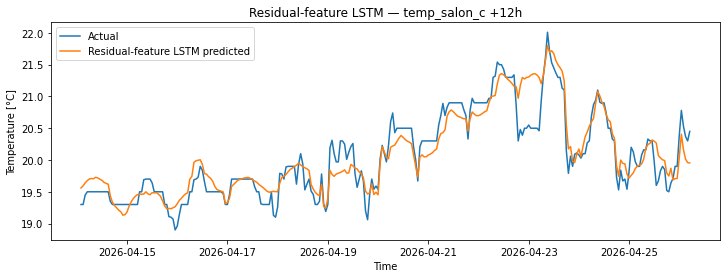

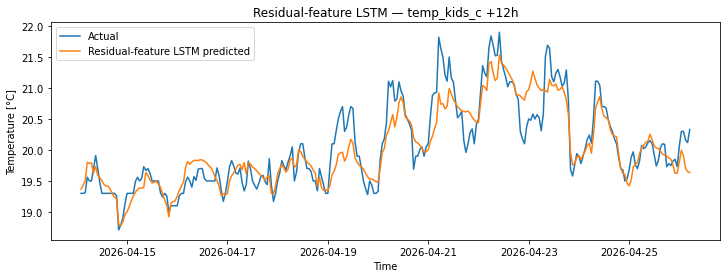

In [73]:
for i, target in enumerate(res_temp_targets):
    plt.figure(figsize=(12, 4))
    plt.plot(res_test_times, res_actual_temp[:, i], label="Actual")
    plt.plot(res_test_times, res_pred_temp[:, i], label="Residual-feature LSTM predicted")
    plt.title(f"Residual-feature LSTM — {target} +{res_horizon}h")
    plt.xlabel("Time")
    plt.ylabel("Temperature [°C]")
    plt.legend()
    room = target.split("_")[1]
    full_path = f"../reports/figures/06_ml_temperature_prediction/RES_LSTM_{room}.png"
    plt.savefig(full_path, dpi=300, facecolor='white')
    plt.show()

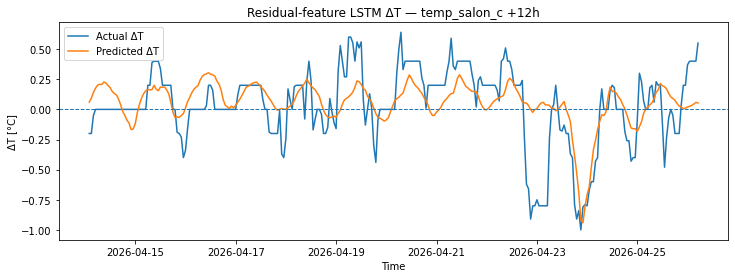

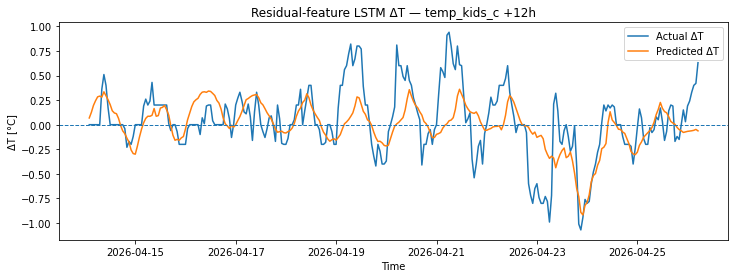

In [74]:
for i, target in enumerate(res_temp_targets):
    plt.figure(figsize=(12, 4))
    plt.plot(res_test_times, res_actual_delta[:, i], label="Actual ΔT")
    plt.plot(res_test_times, res_pred_delta[:, i], label="Predicted ΔT")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Residual-feature LSTM ΔT — {target} +{res_horizon}h")
    plt.xlabel("Time")
    plt.ylabel("ΔT [°C]")
    plt.legend()
    room = target.split("_")[1]
    full_path = f"../reports/figures/06_ml_temperature_prediction/RES_LSTM_ΔΤ_{room}.png"
    plt.savefig(full_path, dpi=300, facecolor='white')
    plt.show()

## 10. Model Comparison

The models are compared using MAE and RMSE over the same 12-hour forecasting horizon.

In [58]:
comparison_df = pd.DataFrame([
    {"Model": "Persistence", "Target": "T(t+12h)", "MAE": mae_persistence, "RMSE": rmse_persistence},
    {"Model": "Random Forest", "Target": "T(t+12h)", "MAE": mae_rf, "RMSE": rmse_rf},
    {"Model": "LSTM", "Target": "T(t+12h)", "MAE": mae_lstm, "RMSE": rmse_lstm},
    {"Model": "Physics-inspired LSTM", "Target": "ΔT(t+12h)", "MAE": mae_delta_lstm, "RMSE": rmse_delta_lstm},
    {"Model": "Physics-inspired LSTM Residuals", "Target": "ΔT(t+12h)", "MAE": mae_res_lstm, "RMSE": rmse_res_lstm},
])
comparison_df

,Model,Target,MAE,RMSE
0,Persistence,T(t+12h),0.263549,0.367761
1,Random Forest,T(t+12h),0.275905,0.367761
2,LSTM,T(t+12h),0.396309,0.507912
3,Physics-inspired LSTM,ΔT(t+12h),0.238481,0.318237
4,Physics-inspired LSTM Residuals,ΔT(t+12h),0.215611,0.287918


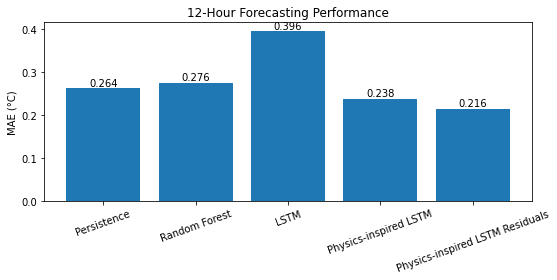

In [76]:
plt.figure(figsize=(8,4))

models = comparison_df["Model"]
mae = comparison_df["MAE"]

bars = plt.bar(models, mae)

plt.ylabel("MAE (°C)")
plt.title("12-Hour Forecasting Performance")

plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 11. Key Takeaways

The results highlight an important lesson:

Model architecture alone is not sufficient.

While the Random Forest and vanilla LSTM models struggle to capture the thermal dynamics of the system, reformulating the problem as prediction of temperature change (ΔT) leads to a substantial improvement.

Adding physics-inspired residual features further improves forecasting accuracy.

This suggests that incorporating physical structure into the learning process can be more valuable than increasing model complexity alone.